# Trabajo Práctico 3

## Objetivo:

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/images` a partir del template `Material_TPs/TP3/template`.

1) Obtener una detección del logo en cada imagen sin falsos positivos
2) Plantear y validar un algoritmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo template del ítem 1
3) Generalizar el algoritmo del ítem 2 para todas las imágenes

Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección

# $$ --- RESOLUCION --- $$

## Configuración

In [ ]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

TEMPLATE_PATH = "template/pattern.png"
IMAGES_DIR = Path("images")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MULTI_IMAGE_NAME = "coca_multi.png"  # imagen con múltiples instancias del logo

plt.rcParams["figure.figsize"] = (10, 6)

## Métrica de similitud y el truco de invarianza a polaridad

Se usa el **coeficiente de correlación cruzada normalizado** (`cv2.TM_CCOEFF_NORMED`), que para una ventana del tamaño del template centra ambas señales restando su media antes de correlacionar:

$$R(x,y) = \frac{\sum_{x',y'} (T(x',y') - \bar T)\,(I(x+x',y+y') - \bar I)}{\sqrt{\sum_{x',y'} (T(x',y') - \bar T)^2 \cdot \sum_{x',y'} (I(x+x',y+y') - \bar I)^2}}$$

Si se invierte la polaridad del template (por ejemplo `T' = 255 - T`, como ocurre cuando el logo aparece en blanco sobre fondo rojo en vez de rojo sobre fondo blanco), entonces `T' - \bar{T'} = -(T - \bar T)`. Como el numerador es lineal en `(T - \bar T)` y el denominador queda igual (todo al cuadrado), resulta:

$$R_{T'}(x,y) = -R_T(x,y)$$

Por lo tanto, tomar **`|R(x,y)|`** hace que la métrica sea invariante a inversiones de polaridad **sin necesidad de preprocesar nada** (ni Canny, ni dos templates). Alcanza con usar el valor absoluto del coeficiente normalizado. Esto es muy útil porque varias fotos reales muestran el logo en blanco sobre fondo rojo, mientras que el template provisto es rojo sobre blanco.

Template: (175, 400)


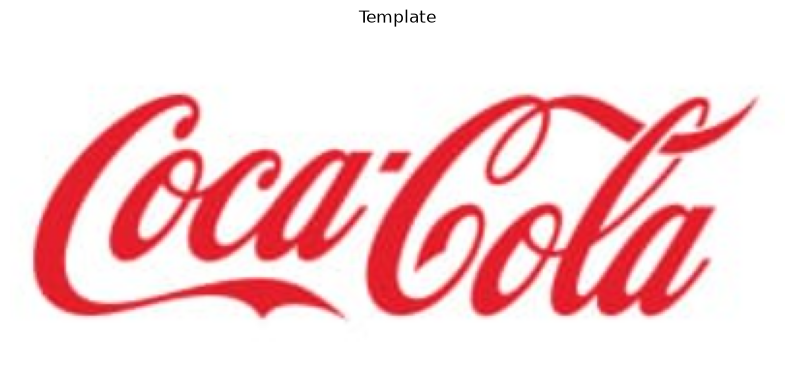

In [3]:
def load_gray(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"No se pudo leer: {path}")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray


template_bgr, template_gray = load_gray(TEMPLATE_PATH)
print("Template:", template_gray.shape)

plt.imshow(cv2.cvtColor(template_bgr, cv2.COLOR_BGR2RGB))
plt.title("Template")
plt.axis("off")
plt.show()

## Matching multiescala

El template matching clásico solo es invariante a traslaciones, por lo que para manejar los distintos tamaños con los que aparece el logo en cada imagen se arma una pirámide de escalas. Se redimensiona el **template** a distintos factores de escala y se corre `matchTemplate` contra la imagen completa en cada una, quedándose con el mejor score global.

**Restricción de tamaño mínimo (`min_width_frac`).** Al escanear escalas muy chicas, un template reducido a pocos píxeles tiende a correlacionar alto con regiones arbitrarias de la imagen "por casualidad" (al tener pocos grados de libertad, cualquier textura puede parecerse). Esto genera falsos positivos con score competitivo frente a una detección real. Para evitarlo, se descartan escalas donde el template redimensionado sea menor a una fracción mínima del ancho de la imagen. Una forma de incorporar la expectativa de que el logo ocupa una porción razonable de la escena, no unos pocos píxeles.


In [4]:
def valid_sizes(tw, th, iw, ih, scales, min_width_frac, max_width_frac=0.95):
    """Filtra las escalas que producen un template de tamaño razonable
    (ni mayor que la imagen, ni menor que `min_width_frac` del ancho de la imagen)."""
    out = []
    for s in scales:
        w, h = int(tw * s), int(th * s)
        if w < 10 or h < 10 or w >= iw or h >= ih:
            continue
        if w < min_width_frac * iw or w > max_width_frac * iw:
            continue
        out.append((s, w, h))
    return out


def match_abs(image_gray, template_resized):
    """NCC normalizado, con valor absoluto para invarianza a polaridad """
    res = cv2.matchTemplate(image_gray, template_resized, cv2.TM_CCOEFF_NORMED)
    return np.abs(res)


def coarse_best_scale(image_gray, template_gray, scales, min_width_frac):
    """Etapa gruesa: recorre las escalas válidas y devuelve (mejor_score, mejor_escala)."""
    th, tw = template_gray.shape
    ih, iw = image_gray.shape
    best = None
    for s, w, h in valid_sizes(tw, th, iw, ih, scales, min_width_frac):
        resized = cv2.resize(template_gray, (w, h))
        res = match_abs(image_gray, resized)
        mx = res.max()
        if best is None or mx > best[0]:
            best = (float(mx), s)
    if best is None:
        return 0.0, None
    return best

## Non-Maximum Suppression

Al colocar un umbral para un mapa de correlación quedan muchos píxeles vecinos por encima del umbral alrededor de cada pico real (la superficie de correlación es suave). Para quedarnos con una única caja por instancia del logo, se aplica NMS clásica. Se ordenan los candidatos por score, se toma el mejor, se descartan los que solapan significativamente con él (IoU alto) y se repite con los que quedan.

In [5]:
def iou(a, b):
    """Intersection-over-Union entre dos cajas (x, y, w, h)."""
    ax1, ay1, aw, ah = a
    bx1, by1, bw, bh = b
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0


def nms(candidates, iou_thresh=0.3):
    """candidates: lista de (score, x, y, w, h). Devuelve la lista filtrada por NMS,
    ordenada de mayor a menor score."""
    candidates = sorted(candidates, key=lambda c: c[0], reverse=True)
    picked = []
    while candidates:
        best = candidates.pop(0)
        picked.append(best)
        candidates = [c for c in candidates if iou(best[1:], c[1:]) < iou_thresh]
    return picked

## Algoritmo de detección (único, para los tres ítems)

`detect_logos` combina todo lo anterior en dos etapas:

1. **Etapa gruesa**: encuentra la escala que da el mejor score global (`coarse_best_scale`). Si ese score no supera `reject_thresh`, se abstiene y **no devuelve ninguna detección**. Se prefiere no detectar antes que arriesgar un falso positivo, como pide el enunciado.
2. **Etapa fina**: refina la búsqueda en una banda angosta alrededor de la mejor escala (`fine_band`), coloca el umbral al mapa de correlación con `score_thresh` y aplica NMS para devolver una detección por instancia real del logo.

Los parámetros `min_width_frac` y `fine_band` se calibran distinto según el escenario:

- **Objeto único, grande en la imagen** (una foto de producto): se espera que el logo ocupe una fracción considerable del ancho → `min_width_frac` alto (p. ej. 0.15).
- **Múltiples instancias chicas** (una góndola con varias botellas): cada instancia ocupa una fracción menor del ancho total → `min_width_frac` más bajo (p. ej. 0.05).

Esto no es "ajustar a mano cada imagen". Es la misma función, parametrizada según una hipótesis razonable sobre la escena (cuánto se espera que ocupe el logo), igual que se elegiría el tamaño de ventana de búsqueda en cualquier sistema real.

In [6]:
def detect_logos(image_gray, template_gray, coarse_scales, min_width_frac,
                  fine_band, score_thresh, nms_iou=0.3, fine_steps=15, reject_thresh=None):
    """Devuelve (detecciones, mejor_escala_gruesa, mejor_score_grueso).

    detecciones: lista de (score, x, y, w, h), una por instancia detectada (post-NMS).
    Si el mejor score de la etapa gruesa no supera `reject_thresh`, devuelve lista vacía.
    """
    th, tw = template_gray.shape
    ih, iw = image_gray.shape

    best_score, best_scale = coarse_best_scale(image_gray, template_gray, coarse_scales, min_width_frac)

    if best_scale is None or (reject_thresh is not None and best_score < reject_thresh):
        return [], best_scale, best_score

    fine_scales = np.linspace(best_scale * (1 - fine_band), best_scale * (1 + fine_band), fine_steps)
    all_candidates = []
    for s, w, h in valid_sizes(tw, th, iw, ih, fine_scales, min_width_frac=0.0):
        resized = cv2.resize(template_gray, (w, h))
        res = match_abs(image_gray, resized)
        ys, xs = np.where(res >= score_thresh)
        for x, y in zip(xs, ys):
            all_candidates.append((float(res[y, x]), int(x), int(y), w, h))

    detections = nms(all_candidates, nms_iou)
    return detections, best_scale, best_score


def draw_detections(img_bgr, detections, color=(0, 255, 0), thickness=2, font_scale=0.6):
    """Dibuja las cajas detectadas con su score de confianza."""
    vis = img_bgr.copy()
    for score, x, y, w, h in detections:
        cv2.rectangle(vis, (x, y), (x + w, y + h), color, thickness)
        label = f"{score:.2f}"
        ty = max(y - 6, 12)
        cv2.putText(vis, label, (x, ty), cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 2, cv2.LINE_AA)
    return vis

## 1 — Una detección por imagen, sin falsos positivos

Se corre `detect_logos` en modo "objeto único" sobre todas las imágenes **excepto** `coca_multi.png`. Se usa `reject_thresh = score_thresh` para que, si la mejor escala global no alcanza una confianza mínima, la imagen quede marcada como "sin detección confiable" en lugar de forzar una caja.

In [7]:
COARSE_SCALES = np.geomspace(0.05, 3.5, 70)

SINGLE_PRESET = dict(
    min_width_frac=0.15,
    fine_band=0.10,
    score_thresh=0.42,
    reject_thresh=0.42,
    nms_iou=0.3,
)

single_image_paths = sorted(
    p for p in IMAGES_DIR.glob("*")
    if p.suffix.lower() in (".png", ".jpg", ".jpeg") and p.name != MULTI_IMAGE_NAME
)
print("Imágenes (detección única):", [p.name for p in single_image_paths])

Imágenes (detección única): ['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']


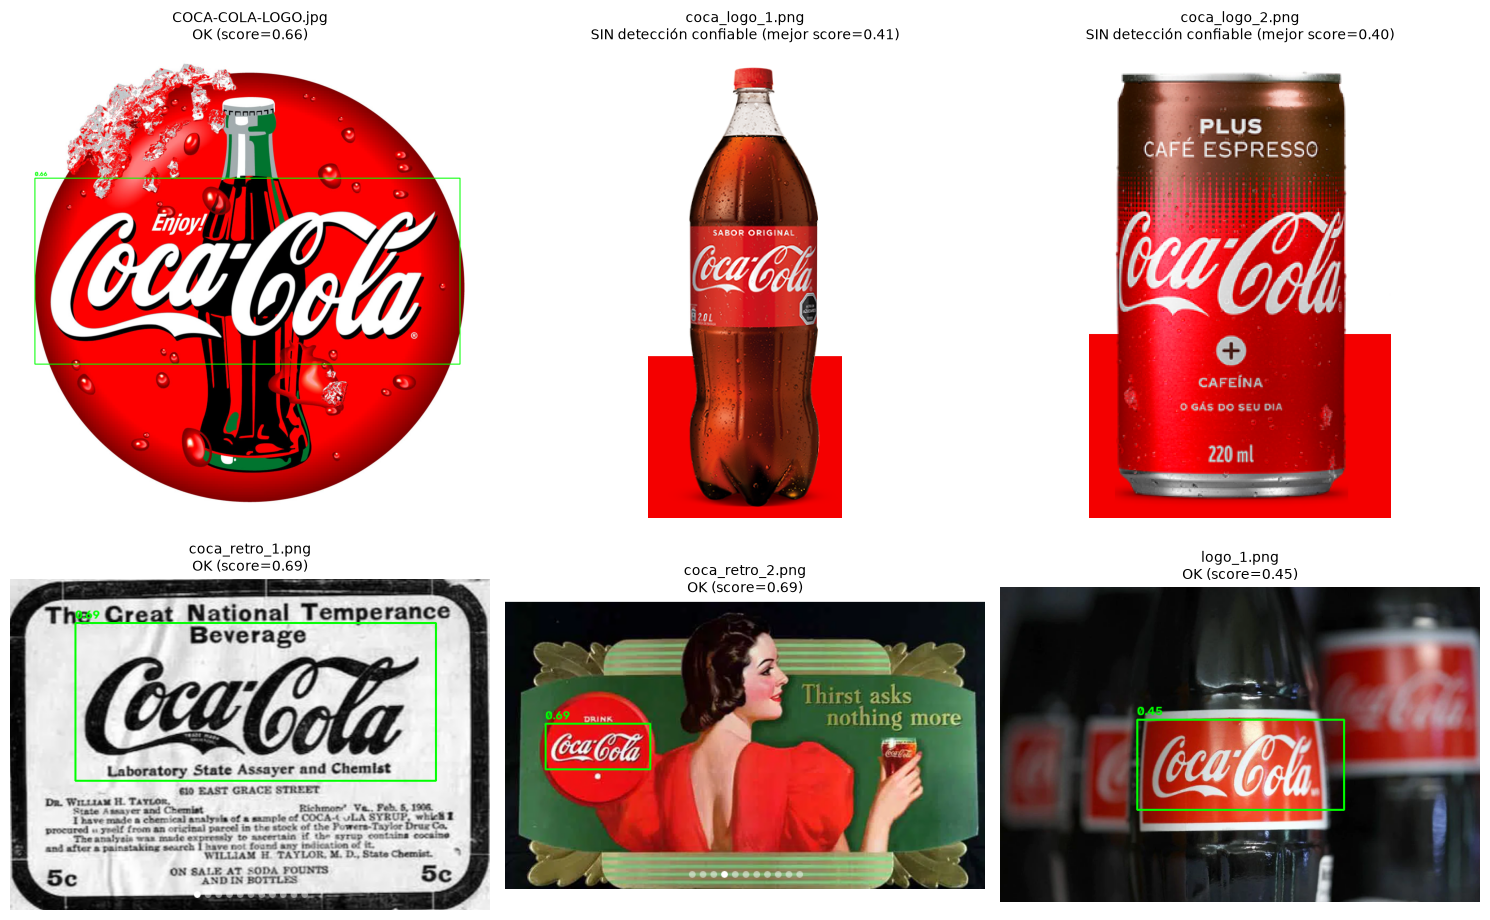


Resumen ítem 1:
  COCA-COLA-LOGO.jpg     -> detectado (score=0.661, escala=3.09)
  coca_logo_1.png        -> rechazado (mejor score=0.412 < umbral)
  coca_logo_2.png        -> rechazado (mejor score=0.405 < umbral)
  coca_retro_1.png       -> detectado (score=0.695, escala=1.31)
  coca_retro_2.png       -> detectado (score=0.690, escala=0.38)
  logo_1.png             -> detectado (score=0.452, escala=0.75)


In [8]:
results_item1 = {}

n = len(single_image_paths)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, path in zip(axes, single_image_paths):
    img_bgr, img_gray = load_gray(path)
    dets, best_scale, best_score = detect_logos(img_gray, template_gray, COARSE_SCALES, **SINGLE_PRESET)
    results_item1[path.name] = (dets, best_scale, best_score)

    vis = draw_detections(img_bgr, dets)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    if dets:
        title = f"{path.name}\nOK (score={dets[0][0]:.2f})"
    else:
        title = f"{path.name}\nSIN detección confiable (mejor score={best_score:.2f})"
    ax.set_title(title, fontsize=10)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "item1_detecciones_unicas.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nResumen ítem 1:")
for name, (dets, scale, score) in results_item1.items():
    estado = f"detectado (score={dets[0][0]:.3f}, escala={scale:.2f})" if dets else f"rechazado (mejor score={score:.3f} < umbral)"
    print(f"  {name:22s} -> {estado}")

La mayoría de las imágenes se detectan con confianza razonable (score > 0.45). Las imágenes `coca_logo_1.png` y `coca_logo_2.png` no superaron el umbral. Esto puede deberse a etiquetas chicas o muy brillantes, con reflejos por la botella de plástico y la lata. En estos casos el algoritmo las reporta como "sin detección confiable" en lugar de dibujar una caja en un lugar incorrecto. Ante la duda, no se afirma nada, como se pide en el enunciado.

Si se quiere forzar una respuesta para esos casos límite, se puede bajar `reject_thresh`, pero eso reintroduce falsos positivos. Es un *trade-off* explícito entre cobertura y precisión. Con `reject_thresh` = 0.41 ya se tiene una detección incorrecta, lo cual valida el valor de 0.42 elegido.

## 2 — Múltiples detecciones en `coca_multi.png`

Acá cada instancia del logo ocupa una fracción mucho menor del ancho de la imagen (son muchas botellas chicas en una góndola), así que se usa un `min_width_frac` más bajo. El resto del algoritmo (escala gruesa → banda fina → umbral → NMS) es exactamente el mismo.

Mejor escala global: 0.233 (score=0.551)
Detecciones finales (post-NMS): 14


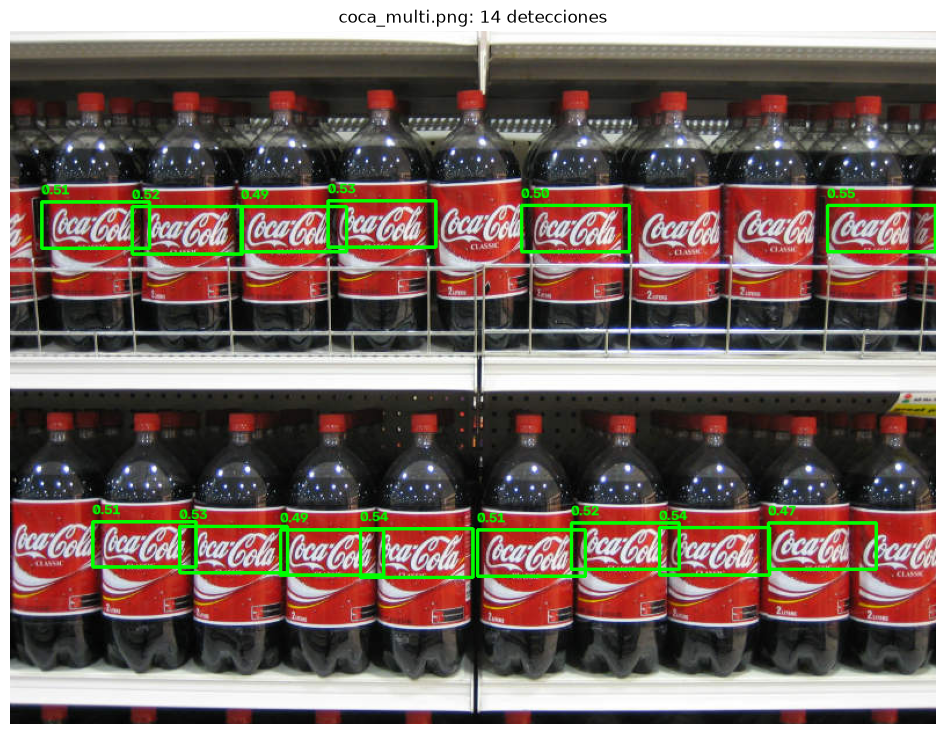

In [9]:
MULTI_PRESET = dict(
    min_width_frac=0.05,
    fine_band=0.15,
    score_thresh=0.46,
    reject_thresh=0.30,
    nms_iou=0.3,
)

multi_path = IMAGES_DIR / MULTI_IMAGE_NAME
multi_bgr, multi_gray = load_gray(multi_path)

dets_multi, best_scale_multi, best_score_multi = detect_logos(
    multi_gray, template_gray, COARSE_SCALES, **MULTI_PRESET
)

print(f"Mejor escala global: {best_scale_multi:.3f} (score={best_score_multi:.3f})")
print(f"Detecciones finales (post-NMS): {len(dets_multi)}")

vis_multi = draw_detections(multi_bgr, dets_multi, thickness=2, font_scale=0.4)
plt.figure(figsize=(12, 9))
plt.imshow(cv2.cvtColor(vis_multi, cv2.COLOR_BGR2RGB))
plt.title(f"{MULTI_IMAGE_NAME}: {len(dets_multi)} detecciones")
plt.axis("off")
plt.savefig(OUTPUT_DIR / "item2_coca_multi_detecciones.png", dpi=150, bbox_inches="tight")
plt.show()

### Validación

Para validar el algoritmo de múltiples detecciones, se realiza lo siguiente:

1) **Conteo manual**: contando de forma visual las etiquetas de "Coca-Cola", se observan 19 botellas, mientras que el algoritmo contó 14. Esas 5 de diferencia, presentan ciertas particularidades, como el nombre un poco recortado o incompleto.
2) **Sensibilidad al umbral**: se repite la detección barriendo `score_thresh` y se grafica la cantidad de detecciones resultantes.

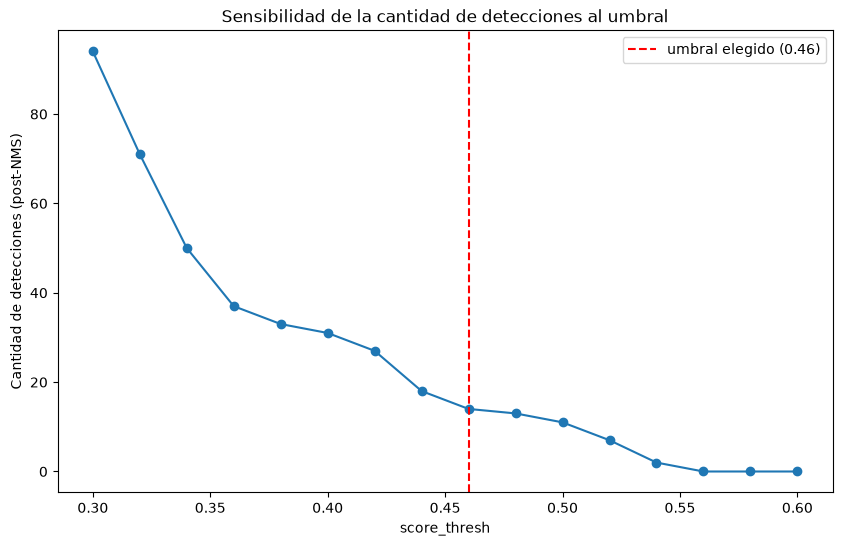

In [10]:
thresholds = np.linspace(0.30, 0.60, 16)
counts = []
for t in thresholds:
    dets, _, _ = detect_logos(
        multi_gray, template_gray, COARSE_SCALES,
        min_width_frac=MULTI_PRESET["min_width_frac"],
        fine_band=MULTI_PRESET["fine_band"],
        score_thresh=t,
        reject_thresh=MULTI_PRESET["reject_thresh"],
        nms_iou=MULTI_PRESET["nms_iou"],
    )
    counts.append(len(dets))

plt.plot(thresholds, counts, marker="o")
plt.axvline(MULTI_PRESET["score_thresh"], color="red", ls="--", label=f"umbral elegido ({MULTI_PRESET['score_thresh']})")
plt.xlabel("score_thresh")
plt.ylabel("Cantidad de detecciones (post-NMS)")
plt.title("Sensibilidad de la cantidad de detecciones al umbral")
plt.legend()
plt.savefig(OUTPUT_DIR / "item2_sensibilidad_umbral.png", dpi=150, bbox_inches="tight")
plt.show()

Para umbrales bajos, el conteo es alto porque entran falsos positivos. Para umbrales muy altos, el conteo cae porque se empiezan a perder instancias reales. Es por eso que el umbral adecuado cae en una "meseta" intermedia donde el conteo es estable, sin falsos positivos. El valor elegido es 0.46

## 3 — Generalizar el algoritmo a todas las imágenes

Se aplica `detect_logos` a **todas** las imágenes de la carpeta, eligiendo el preset (`SINGLE_PRESET` o `MULTI_PRESET`) según si se espera una única instancia grande o varias instancias chicas. Esta elección podría automatizarse (por ejemplo, corriendo primero `SINGLE_PRESET` y, si no hay detección confiable, reintentando con `MULTI_PRESET`), pero aquí se deja explícita para que quede claro qué supuesto de escena se está usando en cada caso.

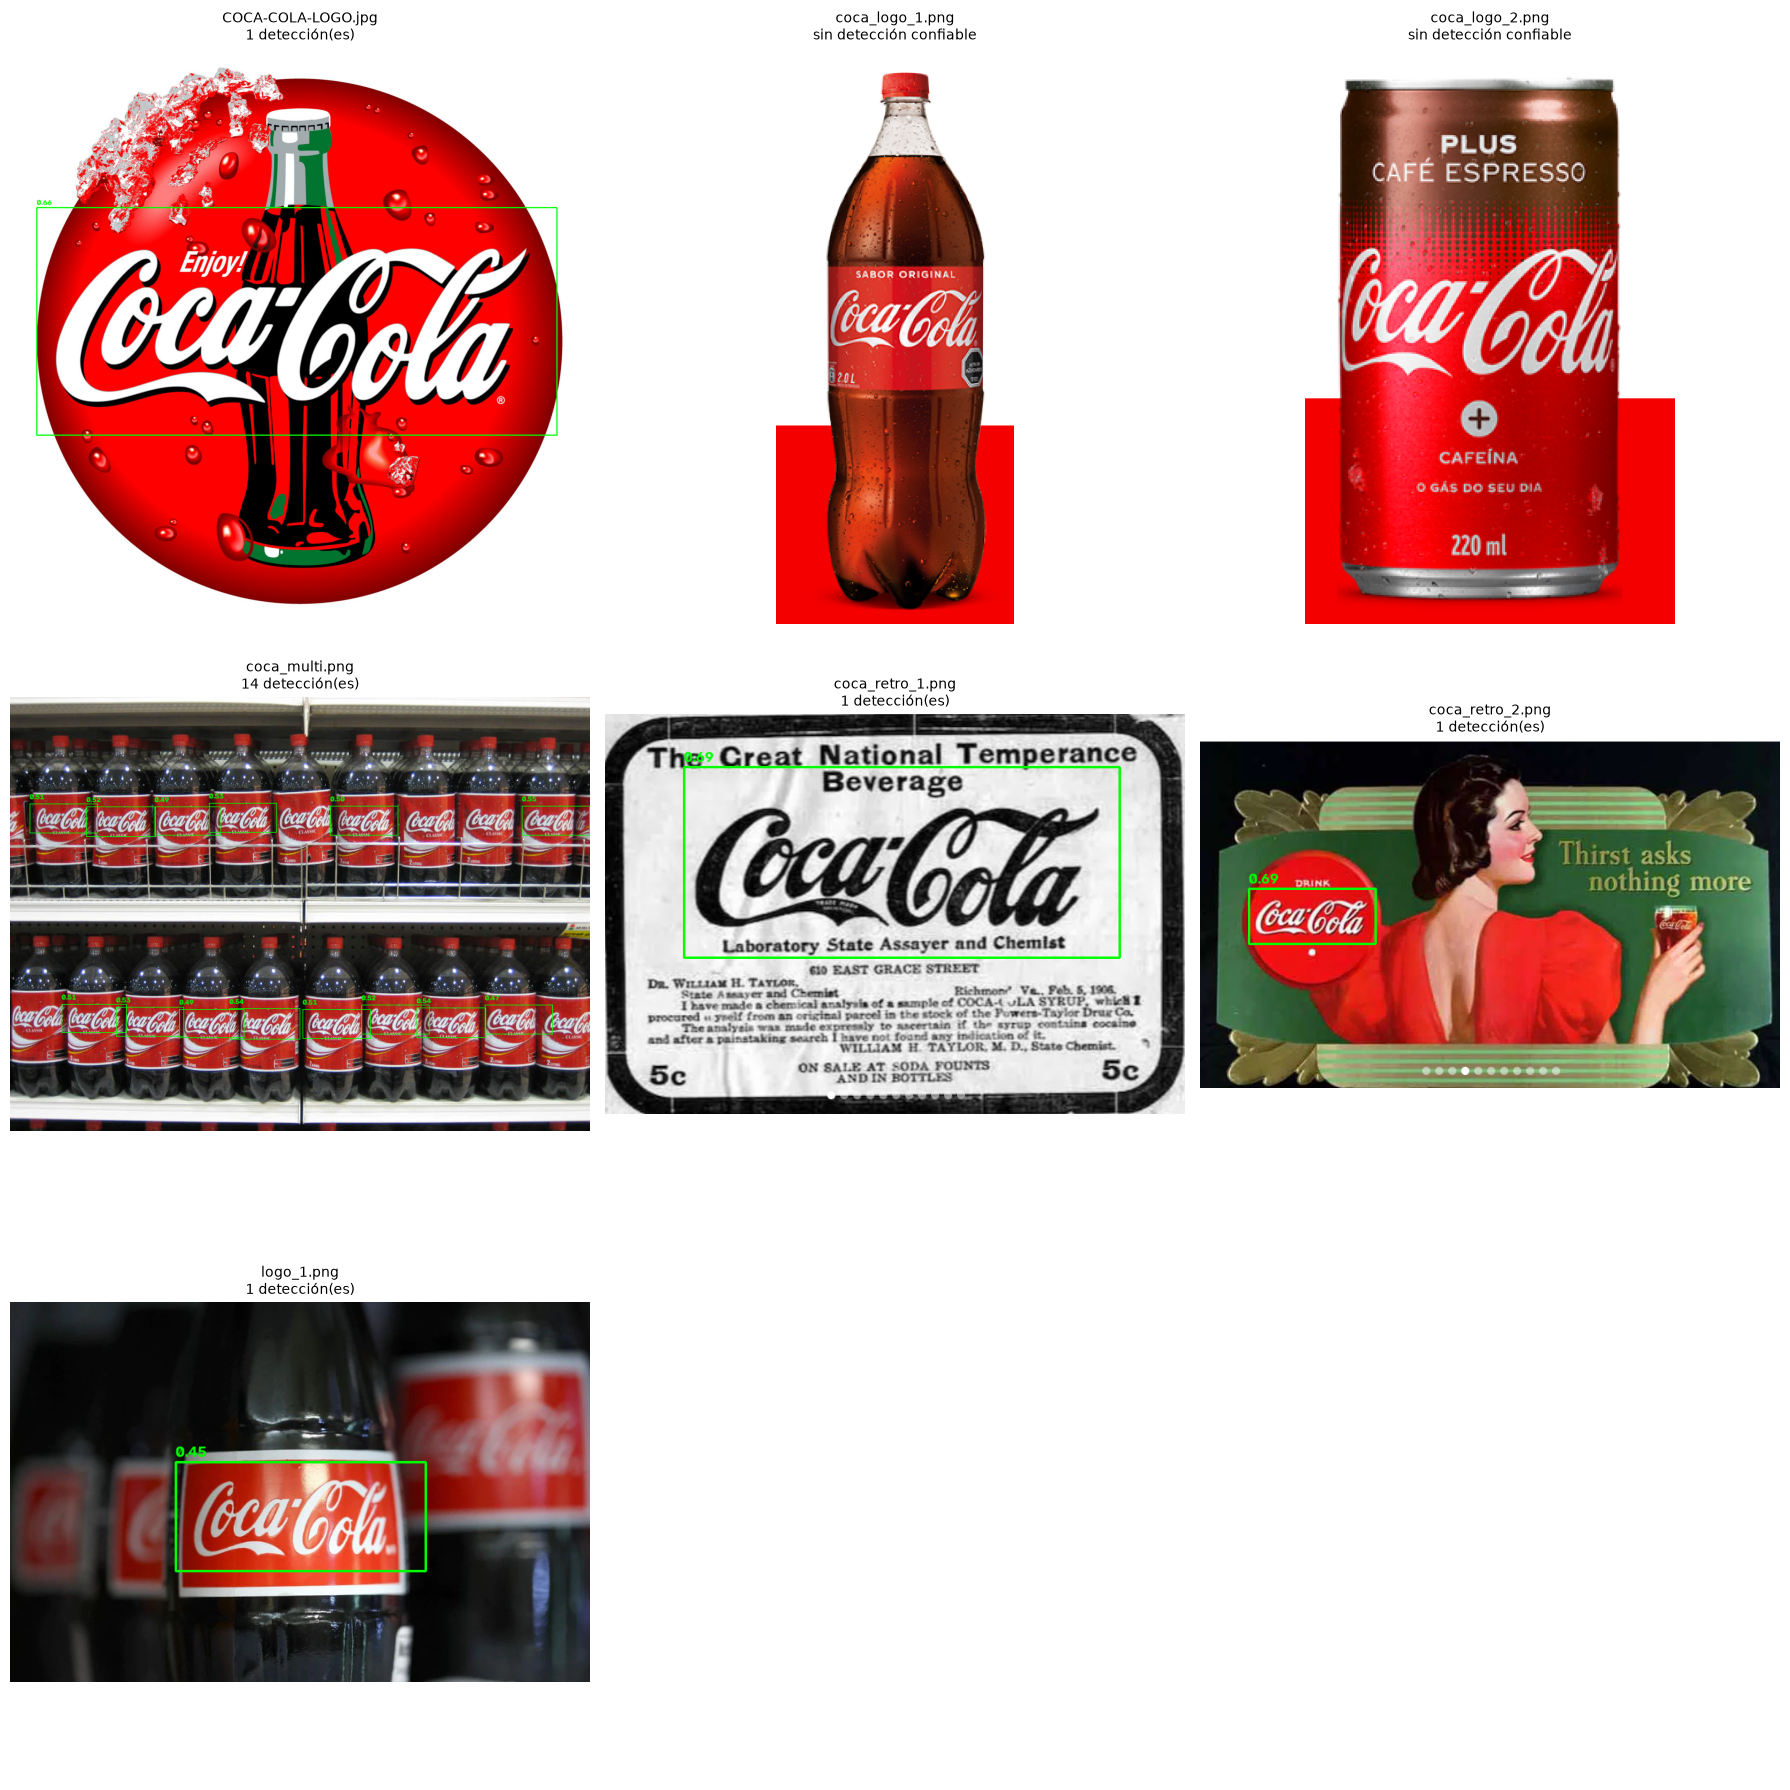

In [11]:
# Mapeo explícito imagen -> preset. Por defecto, todas usan SINGLE_PRESET excepto la góndola.
PRESET_BY_IMAGE = {
    MULTI_IMAGE_NAME: MULTI_PRESET,
}

all_image_paths = sorted(
    p for p in IMAGES_DIR.glob("*") if p.suffix.lower() in (".png", ".jpg", ".jpeg")
)

results_item3 = {}

n = len(all_image_paths)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
axes = np.array(axes).reshape(-1)

for ax, path in zip(axes, all_image_paths):
    preset = PRESET_BY_IMAGE.get(path.name, SINGLE_PRESET)
    img_bgr, img_gray = load_gray(path)
    dets, best_scale, best_score = detect_logos(img_gray, template_gray, COARSE_SCALES, **preset)
    results_item3[path.name] = (dets, best_scale, best_score, preset)

    font_scale = 0.35 if len(dets) > 5 else 0.6
    thickness = 1 if len(dets) > 5 else 2
    vis = draw_detections(img_bgr, dets, thickness=thickness, font_scale=font_scale)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    estado = f"{len(dets)} detección(es)" if dets else "sin detección confiable"
    ax.set_title(f"{path.name}\n{estado}", fontsize=10)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "item3_generalizacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print(f"{'Imagen':25s} {'Preset':15s} {'Escala':>8s} {'Score max':>10s} {'Detecciones':>12s}")
print("-" * 75)
for name, (dets, scale, score, preset) in results_item3.items():
    preset_name = "multi" if preset is MULTI_PRESET else "single"
    scale_str = f"{scale:.2f}" if scale is not None else "-"
    print(f"{name:25s} {preset_name:15s} {scale_str:>8s} {score:10.3f} {len(dets):12d}")

Imagen                    Preset            Escala  Score max  Detecciones
---------------------------------------------------------------------------
COCA-COLA-LOGO.jpg        single              3.09      0.641            1
coca_logo_1.png           single              0.08      0.412            0
coca_logo_2.png           single              0.17      0.405            0
coca_multi.png            multi               0.23      0.551           14
coca_retro_1.png          single              1.31      0.663            1
coca_retro_2.png          single              0.38      0.676            1
logo_1.png                single              0.75      0.448            1


## 8) Conclusiones

- El truco de tomar `abs(TM_CCOEFF_NORMED)` resuelve, sin preprocesamiento adicional, el problema de que el logo aparezca con polaridad invertida (blanco sobre rojo) respecto del template (rojo sobre blanco) en varias de las imágenes.
- El matching multiescala (redimensionar el template y correlacionar en cada escala) es necesario porque el template matching puro solo es invariante a traslaciones, tal como señala la teoría.
- Restringir el tamaño mínimo de búsqueda (`min_width_frac`) es clave. A escalas muy chicas, la correlación encuentra coincidencias espurias con score competitivo frente al logo real, porque templates diminutos tienen pocos grados de libertad y correlacionan alto con cualquier textura por azar.
- El criterio de rechazo explícito (`reject_thresh`) permite cumplir el pedido de "sin falsos positivos" del punto 1. Ante una imagen donde la mejor escala no da confianza suficiente, el algoritmo no reporta nada en lugar de forzar una caja en un lugar incorrecto.
- Generalizar el algoritmo del punto 2 a todas las imágenes no significa usar una única configuración mágica. Se usan dos presets razonables según el tipo de escena esperado (un objeto grande vs. muchas instancias chicas repetidas), aplicados de forma explícita y documentada, no ajustados a mano por imagen.